In [1]:
import cv2
import pickle
import openslide
import numpy as np
import pandas as pd
from torch.nn import Softmax
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

### Load Data

In [19]:
#attention = pd.read_csv('attentions.csv')
#scores = np.load('TCGA-BH-A0B9_visu/hightiles_encoded/1_scores.npy')
#attentions = np.load('/SAN/colcc/Hormad1/analysis/minotaur/attentions/TCGA-E2-A2P5-01Z_attention_scores_v1.npy')
#attentions = np.load('/SAN/colcc/Hormad1/analysis/minotaur/attentions/attentions/TCGA-BRCA/1_TP/Stage/TCGA-BH-A0C1-01Z_True_attention.npy')
#attentions = np.load('/SAN/colcc/Hormad1/analysis/minotaur/attentions/attentions/TCGA-BRCA/1_TP/Stage/TCGA-BH-A0C1-01Z_True_attention.npy')
#attentions = np.load('/SAN/colcc/Hormad1/analysis/minotaur/attentions/attentions/TCGA-BRCA/1_TP/Cancer/TCGA-BH-A0C1-01Z_True_attention.npy')
#keys = pd.read_csv('/SAN/colcc/Hormad1/analysis/minotaur/attentions/attentions/TCGA-BRCA/1_TP/Stage/TCGA-BH-A0C1-01Z_True_tile_keys.txt',delimiter='\t',header=None)
#keys.columns = ['coords']

In [46]:
attentions = np.load('/SAN/colcc/Hormad1/analysis/minotaur/attentions2/attentions/TCGA-BRCA/1_TP/Cancer/TCGA-AR-A5QQ-01Z_True_attention.npy')
keys = pd.read_csv('/SAN/colcc/Hormad1/analysis/minotaur/attentions2/attentions/TCGA-BRCA/1_TP/Cancer/TCGA-AR-A5QQ-01Z_True_tile_keys.txt',delimiter='\t',header=None)
keys.columns = ['coords']


<Figure size 1000x1000 with 0 Axes>

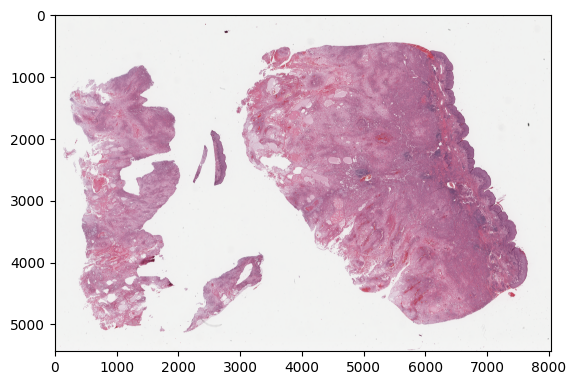

<Figure size 1000x1000 with 0 Axes>

In [30]:
wsi = openslide.OpenSlide('/SAN/colcc/Hormad1/data/WSIs/pantcga/TCGA-AR-A5QQ-01Z-00-DX1.4185D6D2-498E-4E71-8CB3-EDB4739C6229.svs')
thumb = wsi.get_thumbnail(wsi.level_dimensions[2])
thumb = np.array(thumb.convert('RGB'))
plt.imshow(thumb)
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

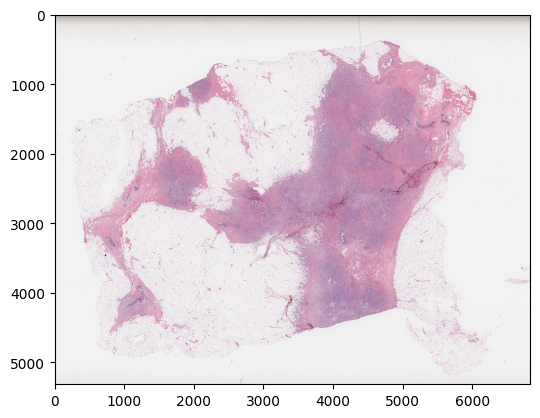

<Figure size 1000x1000 with 0 Axes>

In [7]:
wsi = openslide.OpenSlide('/SAN/colcc/Hormad1/data/WSIs/pantcga/TCGA-BH-A0C1-01Z-00-DX1.21FE357E-B182-4397-BFEF-7E96E994236A.svs')
thumb = wsi.get_thumbnail(wsi.level_dimensions[2])
thumb = np.array(thumb.convert('RGB'))
plt.imshow(thumb)
plt.figure(figsize=(10,10))

### Create overlay

In [31]:
def thresh_image(thumb):
    bilateral1_args={"d":9,"sigmaColor":10000,"sigmaSpace":150}
    bilateral2_args={"d":90,"sigmaColor":5000,"sigmaSpace":5000}
    bilateral3_args={"d":90,"sigmaColor":10000,"sigmaSpace":10000}
    bilateral4_args={"d":90,"sigmaColor":10000,"sigmaSpace":100}
    thresh1_args={"thresh":0,"maxval":255,"type":cv2.THRESH_TRUNC+cv2.THRESH_OTSU}
    thresh2_args={"thresh":0,"maxval":255,"type":cv2.THRESH_OTSU}
    
    img_hsv=cv2.cvtColor(thumb,cv2.COLOR_RGB2HSV)
    lower_red=np.array([150,0,0])
    upper_red=np.array([230,255,255])
    mask=cv2.inRange(img_hsv,lower_red,upper_red)
    img_hsv=cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)
    m=cv2.bitwise_and(thumb,thumb,mask=mask)
    im_fill=np.where(m==0,233,m)
    mask=np.zeros(thumb.shape)
    gray=cv2.cvtColor(im_fill,cv2.COLOR_BGR2GRAY)
    blur1=cv2.bilateralFilter(np.bitwise_not(gray),**bilateral1_args)
    blur2=cv2.bilateralFilter(np.bitwise_not(blur1),**bilateral2_args)
    blur3=cv2.bilateralFilter(np.bitwise_not(blur2),**bilateral3_args)
    blur4=cv2.bilateralFilter(np.bitwise_not(blur3),**bilateral4_args)
    blur_final=255-blur4
    _,thresh = cv2.threshold(blur_final,**thresh1_args)
    _,thresh = cv2.threshold(thresh,**thresh2_args)
    ret,thresh = cv2.threshold(blur_final,25,255,cv2.THRESH_BINARY)
    return thresh

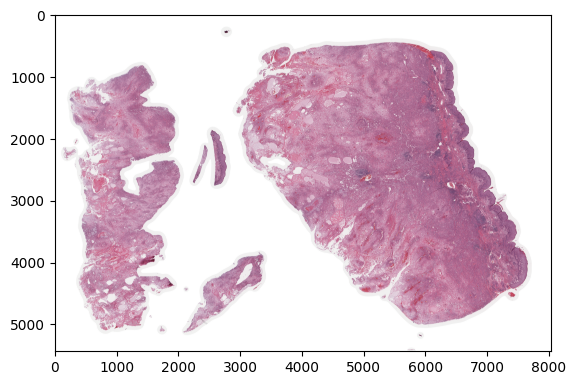

In [32]:
thresh = thresh_image(thumb)
plt.imshow(thresh,cmap='gray')
thumb[:,:,0][thresh==0]=255
thumb[:,:,1][thresh==0]=255
thumb[:,:,2][thresh==0]=255
plt.imshow(thumb)

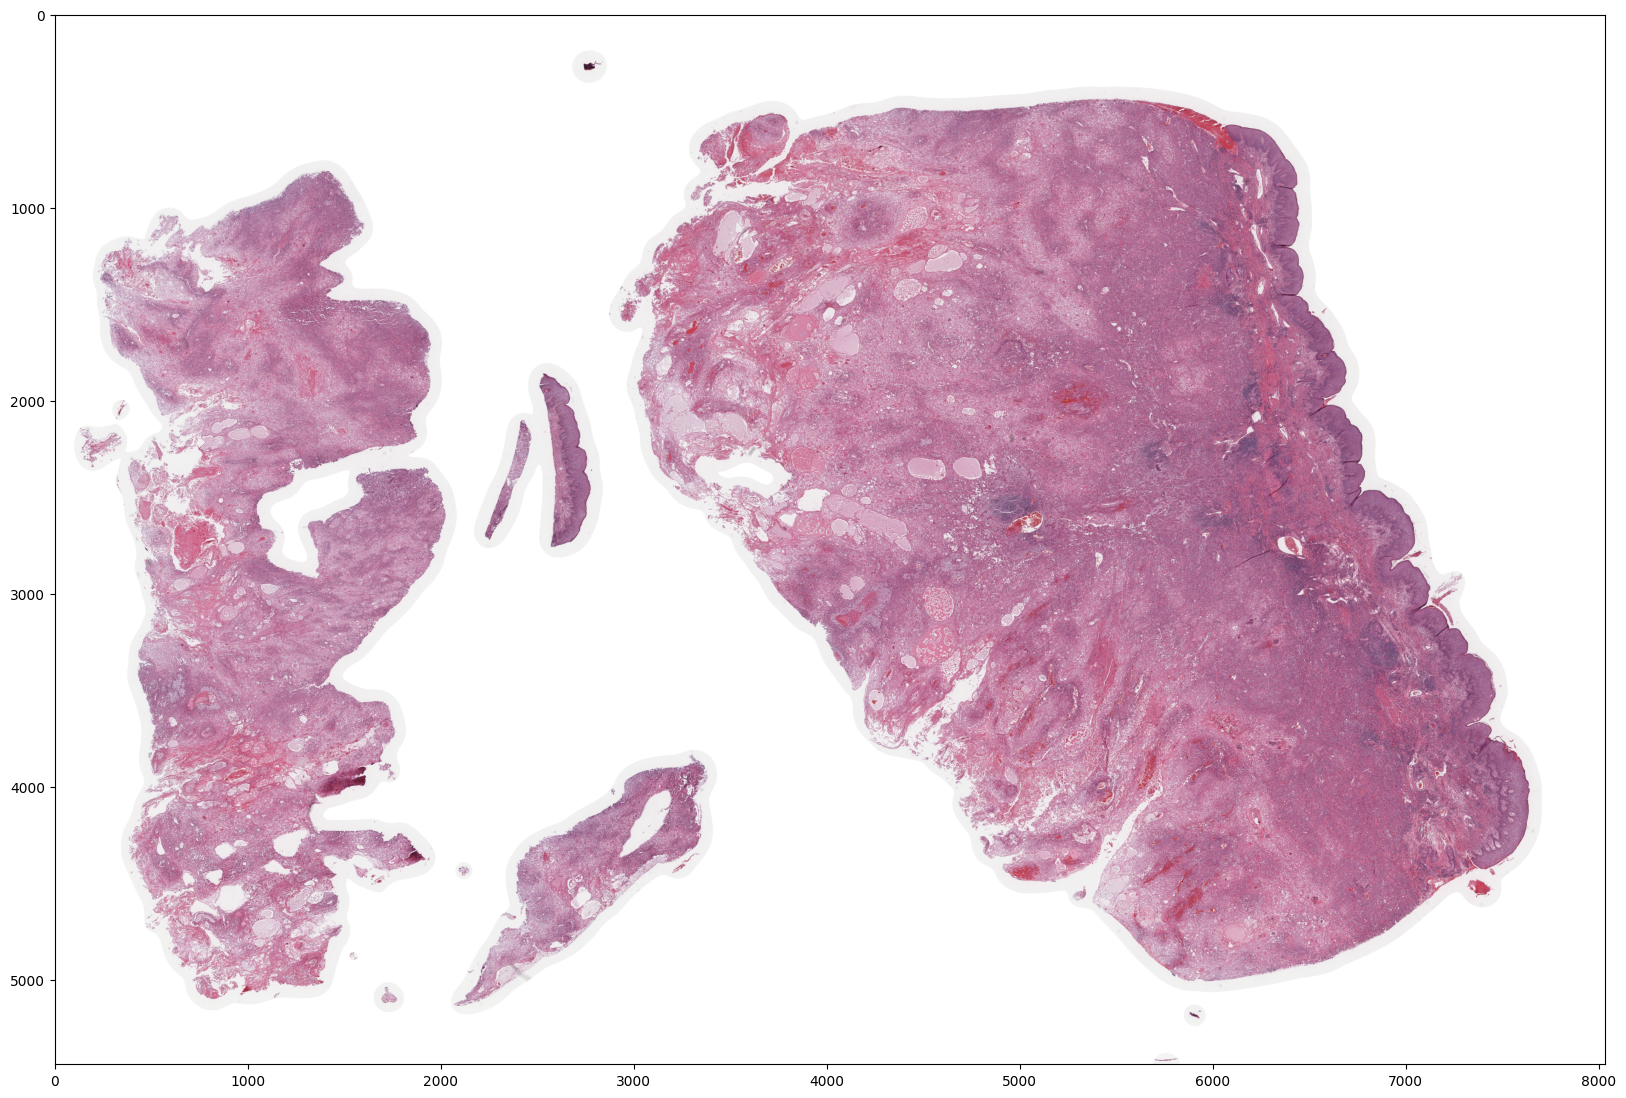

In [53]:
plt.figure(figsize=(20,20))
plt.imshow(thumb)
plt.show()

In [33]:
def norm_att(x, max_a, min_a):
    return (x-min_a)/(max_a-min_a)

In [34]:


def percentile_clip(x, lower=1, upper=99, eps=1e-8):
    """
    Clips and normalizes values in x to the [0,1] range
    based on the given percentile bounds.

    Parameters
    ----------
    x : array-like
        Input array of attention scores (e.g., raw logits).
    lower : float
        Lower percentile for clipping (default 1).
    upper : float
        Upper percentile for clipping (default 99).
    eps : float
        Small value to avoid division by zero.

    Returns
    -------
    clipped_norm : np.ndarray
        Normalized attention scores in [0,1] after clipping.
    """
    # Compute percentile bounds
    low_val = np.percentile(x, lower)
    high_val = np.percentile(x, upper)

    # Clip values outside the percentile range
    x_clipped = np.clip(x, low_val, high_val)

    # Normalize to [0, 1]
    return (x_clipped - low_val) / (high_val - low_val + eps)

In [35]:
def exp(x):
    t = torch.tensor(x)
    s = Softmax(0)
    probs = s(t)
    return probs.numpy()

In [36]:
#atts=list(attentions)
#max_a = max(atts)
#min_a = min(atts)
#atts_norm = list(map(lambda x: norm_att(x, max_a, min_a),atts))

In [37]:
atts=list(attentions)
atts_norm = percentile_clip(atts, lower=1, upper=99, eps=1e-8)

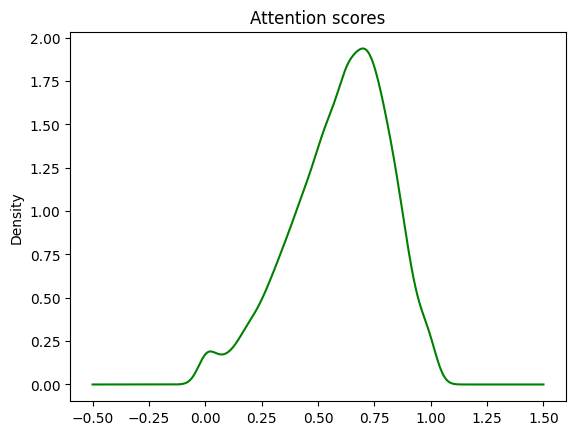

In [38]:
data=pd.DataFrame({'attention':atts_norm})
data.attention.plot.density(color='green')
plt.title('Attention scores')
plt.show()

<Axes: ylabel='Frequency'>

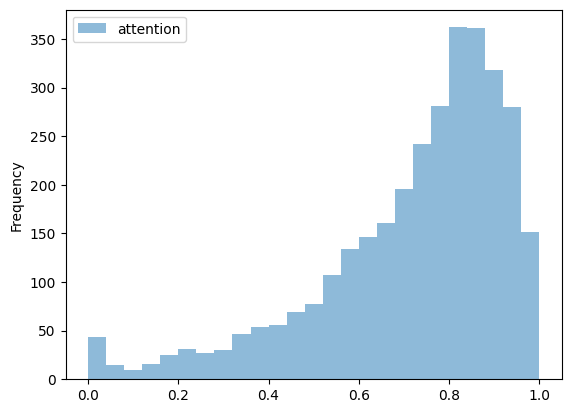

In [12]:
data.plot.hist(bins=25, alpha=0.5)

In [39]:
## build binary map

In [47]:
def overlay_heatmap(atts, coords, s_dim, t_dim, ds=16.002):

    canvas = np.zeros(s_dim)
    for i, a in enumerate(atts):
        tile_heatmap = np.ones((t_dim,t_dim))*a
        x = coords[i][0]
        y = coords[i][1]
        x = int(x/ds)
        y = int(y/ds)
        canvas[y:y+t_dim,x:x+t_dim] = tile_heatmap
    return canvas

In [50]:
coords = list(keys['coords'])
#coords = [c.decode('utf-8') for c in coords]
coords = [(int(c.split('_')[0][2:]), int(c.split('_')[1][:-1])) for c in coords]

In [51]:
np.set_printoptions(suppress=True)

T_DIM = int(224/4)

canvas = overlay_heatmap(atts_norm, coords, thumb.shape[:2], T_DIM)
canvas_new = canvas*255
#pix_values = canvas_new.ravel().tolist()

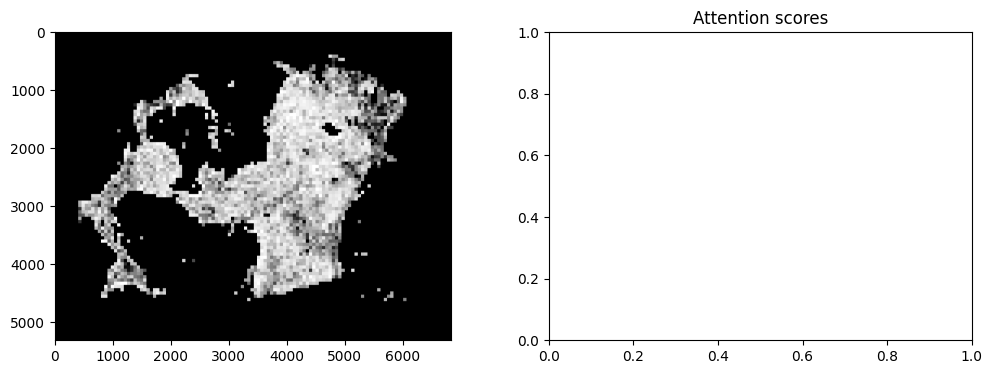

In [17]:
#data = pd.DataFrame({'attention': pix_values})

f, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].imshow(canvas_new,cmap='gray')
#data.attention.plot.density(ax=axes[1],color='green')
plt.title('Attention scores')
plt.show()

In [18]:
#canvas_new = np.where(canvas_new>80,255,0)

### Heatmaps

True

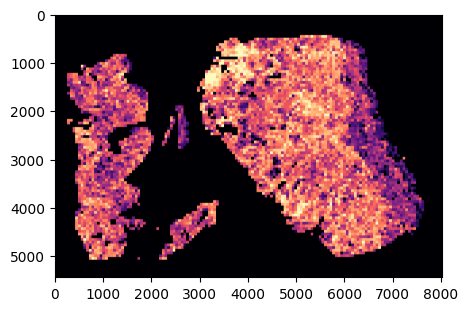

In [52]:
cmap_map = {
    'magma':   cv2.COLORMAP_MAGMA,
    'inferno': cv2.COLORMAP_INFERNO,
    'viridis': cv2.COLORMAP_VIRIDIS,
    # fallback if cividis missing in your OpenCV build
    'cividis': cv2.COLORMAP_CIVIDIS if hasattr(cv2, 'COLORMAP_CIVIDIS') else cv2.COLORMAP_VIRIDIS,
    }

#canvas_new = np.power(canvas_new, 0.98)

heatmap_img = cv2.applyColorMap(canvas_new.astype(np.uint8), cv2.COLORMAP_MAGMA)
heatmap_img = cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(heatmap_img)
cv2.imwrite('testheat.png',heatmap_img)

/tmp/5849143.1.gpu.q/ipykernel_2444/2637501410.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap_image = (plt.cm.get_cmap('magma')(att)[..., :3] * 255).astype(np.uint8)


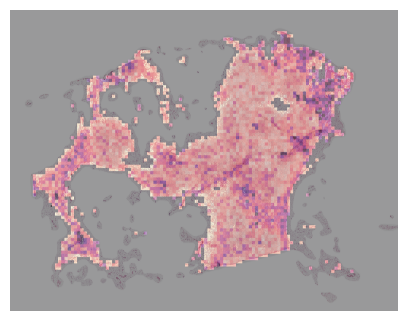

In [20]:
att = canvas
# Map to magma (returns RGBA in [0,1]); drop A and convert to uint8
heatmap_image = (plt.cm.get_cmap('magma')(att)[..., :3] * 255).astype(np.uint8)

# Make sure thumb is RGB uint8 and same size
if thumb.shape[:2] != heatmap_image.shape[:2]:
    heatmap_image = cv2.resize(heatmap_image, (thumb.shape[1], thumb.shape[0]), interpolation=cv2.INTER_NEAREST)

overlayed_image = cv2.addWeighted(heatmap_image, 0.4, thumb, 0.6, 0)

plt.figure(figsize=(5,5))
plt.imshow(overlayed_image)  # expects RGB
plt.axis('off')
plt.show()

(-0.5, 6839.5, 5314.5, -0.5)

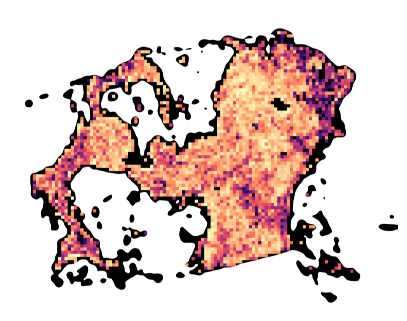

In [21]:
heatmap_image[:,:,0][thresh==0]=255
heatmap_image[:,:,1][thresh==0]=255
heatmap_image[:,:,2][thresh==0]=255
plt.figure(figsize=(5,5))
plt.imshow(heatmap_image)
plt.axis('off')
#plt.savefig('TCGA-BH-A0B9_heatmap.png')

In [27]:
canvas.dtype

dtype('float64')

In [32]:
np.unique(canvas)

array([0.        , 0.00278166, 0.00434276, ..., 0.99954017, 0.99981792,
       1.        ])

/tmp/5849143.1.gpu.q/ipykernel_2444/4086157834.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('magma')  # This colormap goes from blue to red


(-0.5, 6839.5, 5314.5, -0.5)

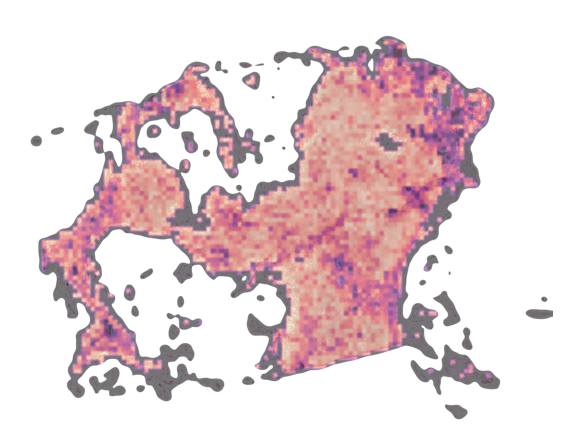

In [22]:
sigma = 10
alpha = 0.4
smoothed_attention = gaussian_filter(canvas, sigma=sigma, mode='constant')
color_map = plt.cm.get_cmap('magma')  # This colormap goes from blue to red
colors = color_map(smoothed_attention)
overlayed_image = cv2.addWeighted(((colors[:,:,0:3]*255)).astype(np.uint8), 0.5, thumb, 0.5, 0)
plt.figure(figsize=(7,7))
overlayed_image[:,:,0][thresh==0]=255
overlayed_image[:,:,1][thresh==0]=255
overlayed_image[:,:,2][thresh==0]=255
plt.imshow(overlayed_image)
plt.axis('off')
#plt.savefig('overlayed_heatmap.png')


In [ ]:
super_imposed_img = cv2.addWeighted(heatmap_img, 0.3, thumb, 0.7, 0)
plt.figure(figsize=(10,10))
plt.imshow(super_imposed_img)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

attention_values = canvas
color_map = plt.cm.get_cmap('magma')  
colors = color_map(attention_values)

# Create a heatmap image
heatmap_image = np.zeros((attention_values.shape[0], attention_values.shape[1], 3))
for i in range(3):
    heatmap_image[..., i] = colors[:, :, i]

original_image = thumb

# Overlay the heatmap on the original image
alpha = 0.6
overlayed_image = alpha * heatmap_image + (1 - alpha) * original_image
overlayed_image = cv2.addWeighted((heatmap_image*255).astype(np.uint8), 0.4, thumb, 0.6, 0)

plt.figure(figsize=(10,10))
plt.imshow(overlayed_image.astype(np.uint8))
plt.axis('off')
plt.show()

In [ ]:
   def heatmap_viridis(self):
        normed = self.canvas.astype(np.float32)
        normed = (normed - normed.min()) / (normed.ptp())  
        rgb = cm.viridis(normed)[:, :, :3]  # RGBA → RGB
        rgb = (rgb * 255).astype(np.uint8)
        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        return bgr

In [ ]:
#return [(int(c.split('_')[0][2:]), int(c.split('_')[1][:-1])) for c in keys]

In [ ]:
   smoothed_attention = gaussian_filter(attention_values, sigma=sigma, mode='constant')
        denom = smoothed_attention.max() - smoothed_attention.min()
        smoothed_attention_norm = (smoothed_attention - smoothed_attention.min()) / denom
        
        color_map = plt.cm.get_cmap('magma')
        colors = color_map(smoothed_attention_norm)

        heatmap_rgb = (colors[:, :, :3] * 255).astype(np.uint8)

        base_img = self.wsi_img
        if base_img.shape[2] == 4:
            base_img = base_img[:, :, :3]
        base_img = base_img.astype(np.uint8)

        overlayed_image = cv2.addWeighted(heatmap_rgb, alpha, base_img, 1 - alpha, 0)

        return overlayed_image